In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import re


In [17]:
# Load the combined results (ensure the path matches your logs folder)
df = pd.read_excel("logs\\1_head_model_systematic_experiments\\experiments_summary.xlsx")
if 'map' in df.columns:
    # Convert map list to string so it can be used for grouping
    df['Config_Group'] = df['map'].astype(str)
else:
    # Fallback: Group by everything that isn't a timestamp or run number
    # This removes the date/time prefix from your example
    df['Config_Group'] = df['model_id'].apply(lambda x: re.sub(r'^\d{2}-\d{2}_\d{2}-\d{2}-\d{2}_', '', str(x)))
    df['Config_Group'] = df['Config_Group'].apply(lambda x: re.sub(r'_r\d+\.pkl$', '', x))
df_clean = df.dropna(subset=['global open R2'])
df_clean = df_clean[df_clean['global open R2'] > 0].copy() # Filter crashed runs

# Count how many seeds we have per group
group_counts = df_clean['Config_Group'].value_counts()
valid_groups = group_counts[group_counts >= 3].index.tolist()
df_final = df_clean[df_clean['Config_Group'].isin(valid_groups)]

print(f"Unique Configurations found: {len(valid_groups)}")
print(f"Total experiments analyzed: {len(df_final)}")

Unique Configurations found: 4
Total experiments analyzed: 40


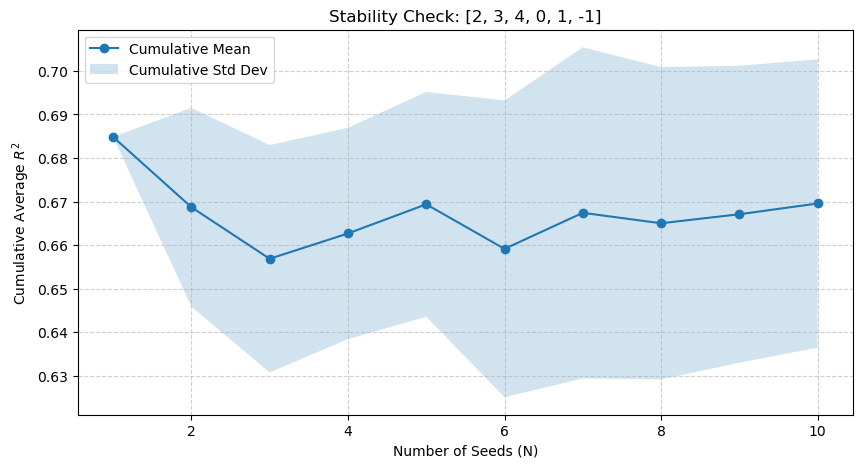

In [18]:
def plot_convergence_stability(df, config_name):
    # Filter data for one specific configuration (e.g., the best one)
    subset = df[df['Config_Group'] == config_name].sort_values('run')
    
    # Calculate cumulative mean and standard error
    subset['cum_mean'] = subset['global open R2'].expanding().mean()
    subset['cum_std'] = subset['global open R2'].expanding().std()
    
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(subset) + 1), subset['cum_mean'], marker='o', label='Cumulative Mean')
    plt.fill_between(range(1, len(subset) + 1), 
                     subset['cum_mean'] - subset['cum_std'].fillna(0), 
                     subset['cum_mean'] + subset['cum_std'].fillna(0), 
                     alpha=0.2, label='Cumulative Std Dev')
    
    plt.title(f"Stability Check: {config_name}")
    plt.xlabel("Number of Seeds (N)")
    plt.ylabel("Cumulative Average $R^2$")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Run it for your top performing configuration
top_config = df_final.groupby('Config_Group')['global open R2'].median().idxmax()
plot_convergence_stability(df_final, top_config)

In [19]:
# Group by Configuration and calculate precision metrics
sufficiency_stats = df_final.groupby('Config_Group')['global open R2'].agg(['mean', 'std', 'count'])
sufficiency_stats['SEM'] = sufficiency_stats['std'] / np.sqrt(sufficiency_stats['count'])

# Calculate the Relative Margin of Error (at 95% confidence)
# Formula: (1.96 * SEM) / Mean
sufficiency_stats['Precision_Error_%'] = (1.96 * sufficiency_stats['SEM']) / sufficiency_stats['mean'].abs() * 100

print("--- Sample Size Sufficiency Analysis ---")
print(sufficiency_stats[['mean', 'std', 'SEM', 'Precision_Error_%']].sort_values('mean', ascending=False).head(5))

--- Sample Size Sufficiency Analysis ---
                         mean       std       SEM  Precision_Error_%
Config_Group                                                        
[2, 3, 4, 0, 1, -1]  0.669555  0.033106  0.010469           3.064599
[4, 0, 1, 2, 3, -1]  0.606526  0.041836  0.013230           4.275213
[0, 1, 4, 2, 3, -1]  0.574923  0.045685  0.014447           4.925124
[4, 2, 3, 0, 1, -1]  0.466520  0.034548  0.010925           4.589949



--- Normality Check (Best Config) ---
Shapiro-Wilk p-value: 0.656668 | Normal: True

--- Statistical Impact of Map Choice ---
Kruskal-Wallis p-value: 0.0000013723
Significant difference? YES


C:\Users\uxueb\AppData\Local\Temp\ipykernel_75788\1052938366.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Config_Group', y='global open R2', data=df_plot,


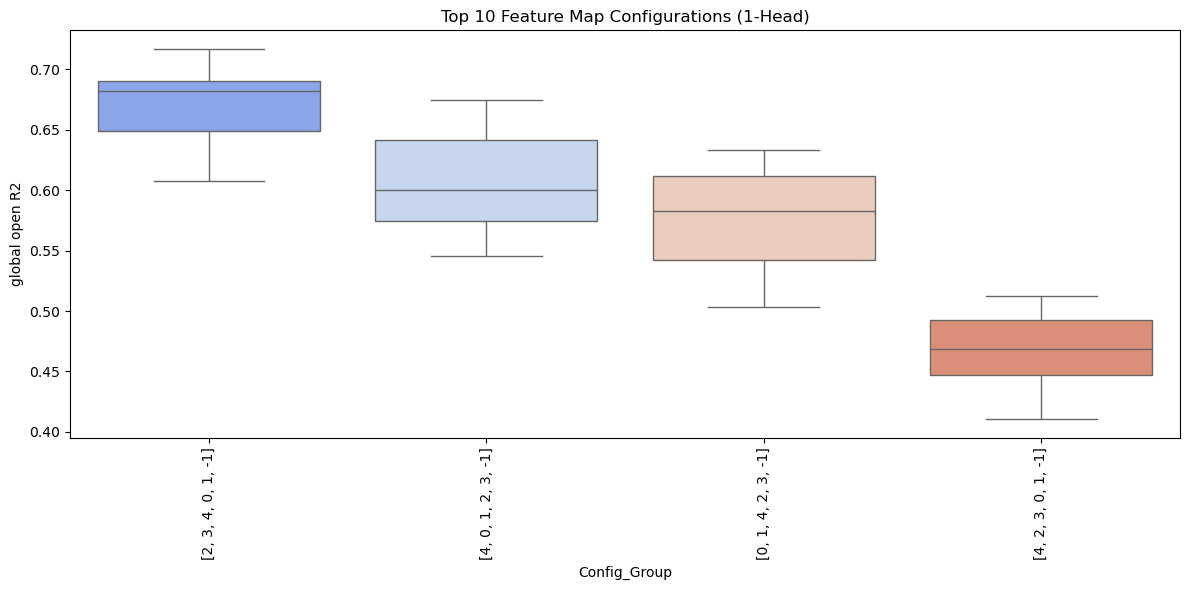

In [20]:


if len(valid_groups) < 2:
    print("Error: Could not find multiple groups. Check if 'map' or 'model_id' allows grouping.")
else:
    # 4. Normality Check for the best configuration
    best_config = df_final.groupby('Config_Group')['global open R2'].median().idxmax()
    best_data = df_final[df_final['Config_Group'] == best_config]['global open R2'].values
    
    stat, p = stats.shapiro(best_data)
    print(f"\n--- Normality Check (Best Config) ---")
    print(f"Shapiro-Wilk p-value: {p:.6f} | Normal: {p > 0.05}")

    # 5. Non-Parametric Comparison
    groups_data = [df_final[df_final['Config_Group'] == g]['global open R2'] for g in valid_groups]
    h_stat, p_kw = stats.kruskal(*groups_data)
    
    print(f"\n--- Statistical Impact of Map Choice ---")
    print(f"Kruskal-Wallis p-value: {p_kw:.10f}")
    print(f"Significant difference? {'YES' if p_kw < 0.05 else 'NO'}")

    # 6. Top 10 Configurations Plot
    plt.figure(figsize=(12, 6))
    # Get top 10 groups by median
    top_10_groups = df_final.groupby('Config_Group')['global open R2'].median().sort_values(ascending=False).head(10).index
    df_plot = df_final[df_final['Config_Group'].isin(top_10_groups)]
    
    sns.boxplot(x='Config_Group', y='global open R2', data=df_plot, 
                order=top_10_groups, palette="coolwarm")
    plt.xticks(rotation=90)
    plt.title("Top 10 Feature Map Configurations (1-Head)")
    plt.tight_layout()
    plt.show()

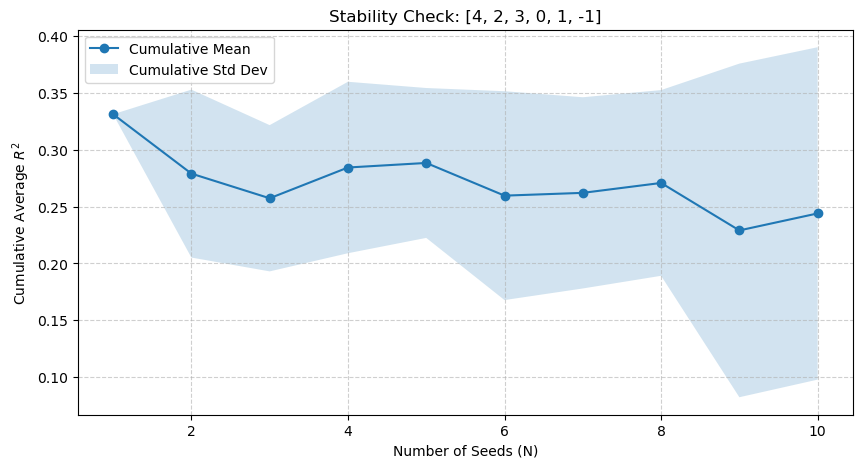

In [21]:
def plot_convergence_stability(df, config_name):
    # Filter data for one specific configuration (e.g., the best one)
    subset = df[df['Config_Group'] == config_name].sort_values('run')
    
    # Calculate cumulative mean and standard error
    subset['cum_mean'] = subset['global closed R2'].expanding().mean()
    subset['cum_std'] = subset['global closed R2'].expanding().std()
    
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(subset) + 1), subset['cum_mean'], marker='o', label='Cumulative Mean')
    plt.fill_between(range(1, len(subset) + 1), 
                     subset['cum_mean'] - subset['cum_std'].fillna(0), 
                     subset['cum_mean'] + subset['cum_std'].fillna(0), 
                     alpha=0.2, label='Cumulative Std Dev')
    
    plt.title(f"Stability Check: {config_name}")
    plt.xlabel("Number of Seeds (N)")
    plt.ylabel("Cumulative Average $R^2$")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Run it for your top performing configuration
top_config = df_final.groupby('Config_Group')['global closed R2'].median().idxmax()
plot_convergence_stability(df_final, top_config)

In [22]:
# Group by Configuration and calculate precision metrics
sufficiency_stats = df_final.groupby('Config_Group')['global closed R2'].agg(['mean', 'std', 'count'])
sufficiency_stats['SEM'] = sufficiency_stats['std'] / np.sqrt(sufficiency_stats['count'])

# Calculate the Relative Margin of Error (at 95% confidence)
# Formula: (1.96 * SEM) / Mean
sufficiency_stats['Precision_Error_%'] = (1.96 * sufficiency_stats['SEM']) / sufficiency_stats['mean'].abs() * 100

print("--- Sample Size Sufficiency Analysis ---")
print(sufficiency_stats[['mean', 'std', 'SEM', 'Precision_Error_%']].sort_values('mean', ascending=False).head(5))

--- Sample Size Sufficiency Analysis ---
                         mean       std       SEM  Precision_Error_%
Config_Group                                                        
[4, 2, 3, 0, 1, -1]  0.243982  0.146197  0.046232          37.139611
[4, 0, 1, 2, 3, -1] -0.085331  0.134931  0.042669          98.007739
[2, 3, 4, 0, 1, -1] -0.606495  0.687858  0.217520          70.295549
[0, 1, 4, 2, 3, -1] -0.648550  0.161171  0.050967          15.402767



--- Normality Check (Best Config) ---
Shapiro-Wilk p-value: 0.030523 | Normal: False

--- Statistical Impact of Map Choice ---
Kruskal-Wallis p-value: 0.0000017155
Significant difference? YES


C:\Users\uxueb\AppData\Local\Temp\ipykernel_75788\2584617979.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Config_Group', y='global closed R2', data=df_plot,


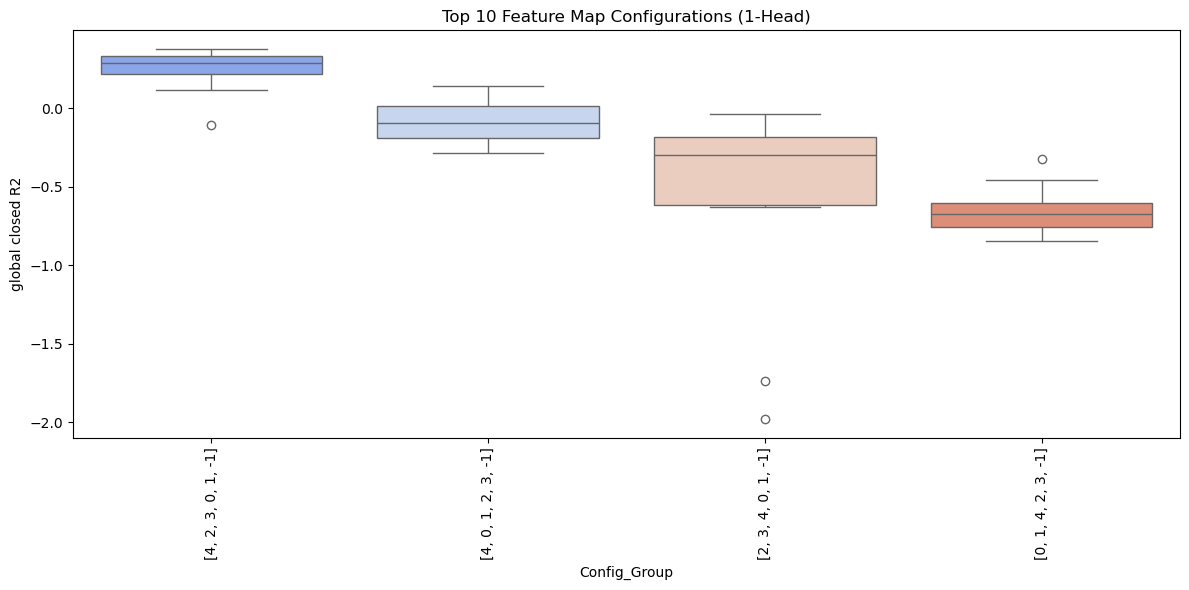

In [23]:
if len(valid_groups) < 2:
    print("Error: Could not find multiple groups. Check if 'map' or 'model_id' allows grouping.")
else:
    # 4. Normality Check for the best configuration
    best_config = df_final.groupby('Config_Group')['global closed R2'].median().idxmax()
    best_data = df_final[df_final['Config_Group'] == best_config]['global closed R2'].values
    
    stat, p = stats.shapiro(best_data)
    print(f"\n--- Normality Check (Best Config) ---")
    print(f"Shapiro-Wilk p-value: {p:.6f} | Normal: {p > 0.05}")

    # 5. Non-Parametric Comparison
    groups_data = [df_final[df_final['Config_Group'] == g]['global closed R2'] for g in valid_groups]
    h_stat, p_kw = stats.kruskal(*groups_data)
    
    print(f"\n--- Statistical Impact of Map Choice ---")
    print(f"Kruskal-Wallis p-value: {p_kw:.10f}")
    print(f"Significant difference? {'YES' if p_kw < 0.05 else 'NO'}")

    # 6. Top 10 Configurations Plot
    plt.figure(figsize=(12, 6))
    # Get top 10 groups by median
    top_10_groups = df_final.groupby('Config_Group')['global closed R2'].median().sort_values(ascending=False).head(10).index
    df_plot = df_final[df_final['Config_Group'].isin(top_10_groups)]
    
    sns.boxplot(x='Config_Group', y='global closed R2', data=df_plot, 
                order=top_10_groups, palette="coolwarm")
    plt.xticks(rotation=90)
    plt.title("Top 10 Feature Map Configurations (1-Head)")
    plt.tight_layout()
    plt.show()